In [40]:
"""
Imports

"""

import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import numpy as np

import torch

from torch.utils.data import IterableDataset

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool

import h5py
import torch.nn.functional as F
#from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses

from torch.utils.data import Dataset, DataLoader, random_split

from torch_geometric.loader import DataLoader

import sys

sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import *
from src.models.gnn import *
from src.models.contrastive_learning import *



In [3]:

"""
Loading ColliderML (ttbar) data

"""

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits", "particles"],
    "split": "train",
    "lazy": False,
    "max_events": 12800,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"][9600:10400]

particles1 = frames1["particles"][9600:10400]

calo_hits = calo_hits1




"""
Data Preprocessor

"""

class ColliderMLHits(IterableDataset):
    def __init__(
        self, calo_hits, split, shuffle_files=False, train_fraction=0.8):
        """
        Initialize the dataset.

        Args:
            calo_hits : calo_hit data for events.
            shuffle_files (bool): Whether to shuffle the order of parquet files.
        """
        
        self.calo_hits = calo_hits
        self.shuffle_files = shuffle_files
        

        self.split = split
        if self.split is not None:
            split_index = int(len(self.calo_hits) * train_fraction)
            if self.split == "train":
                self.calo_hits = self.calo_hits[:split_index]
            elif self.split == "val":
                self.calo_hits = self.calo_hits[split_index:]

        if self.shuffle_files:
            self.shuffle_shards()

    def __len__(self):
        """
        Return the number of events in the dataset.
        """
        return len(self.calo_hits) 

    def shuffle_shards(self):
        """
        Shuffle the events in calo_hits
        """
        random.shuffle(self.calo_hits)

    def __iter__(self):
        logger = logging.getLogger(__name__)
        self.sample_counter = 0  # Reset sample counter for each iteration or each epoch
        #worker_info = torch.utils.data.get_worker_info()
        

        
        data = self.calo_hits
        
        for event_i in range(len(self.calo_hits)):

            data_i = data[event_i]

            calo_hit_features = np.column_stack(
                (
                    data_i['x'].to_numpy()[0],
                    data_i['y'].to_numpy()[0],
                    data_i['z'].to_numpy()[0],
                    data_i['total_energy'].to_numpy()[0]

                )
            )

            f_i = len(data_i['x'].to_numpy()[0]) if len(data_i['x'].to_numpy()[0])<8000 else 8000

            yield {

                "calo_hit_features": calo_hit_features

            }
         


"""

Preparing dataset

"""

augment = Compose([
    RandomRotateXY((0, 2*np.pi))
    ,
    RandomShift((20.0, 20.0, 0.0)),
    RandomSpatialCrop(0.7),
    EnergyWhiteNoise(0.002)
])


dataset_test_ = ColliderMLHits(calo_hits, "val", shuffle_files=False, train_fraction=0.0)

#dataset_train = ContrastiveLearningGraphDataset(ContrastiveLearningDataset(dataset_train, augment), builder=EventGraphBuilder(radius=5))
dataset_test = ContrastiveLearningGraphDataset(ContrastiveLearningDataset(dataset_test_, augment), builder=EventGraphBuilder(radius=5))




In [25]:
sum(particles1[0]['energy'][0])

32292.02864800715

In [24]:
sum(calo_hits1[0]['total_energy'][0])

23.495166812070238

In [4]:
### Loading the trained model

model1 = GNNEncoder()
model2 = GNNEncoder()
model3 = GNNEncoder()


prev_weights1 = torch.load('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/model_epoch_18.pth')
prev_weights2 = torch.load('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/model_epoch_18.pth')
prev_weights3 = torch.load('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/model_epoch_18.pth')


model1.load_state_dict(prev_weights1)
model2.load_state_dict(prev_weights2)
model3.load_state_dict(prev_weights3)

model1.projection_head = nn.Identity()
model2.projection_head = nn.Identity()
model3.projection_head = nn.Identity()

In [5]:
## Evaluating the model
from torch_geometric.loader import DataLoader

latents_test1 = []
latents_test2 = []
latents_test3 = []

device = 'cuda'

model1 = model1.to(device)
model1.eval()

model2 = model2.to(device)
model2.eval()

model3 = model3.to(device)
model3.eval()



loader = DataLoader(dataset_test, batch_size=64, shuffle=False)

with torch.no_grad():
    for graph,_ in tqdm(loader):

        #print('ok')
    
        graph = graph.to(device)
        
        latent1 = model1(graph)
        latent2 = model2(graph)
        latent3 = model3(graph)

        #print('ok')
        latents_test1.append(latent1.detach())
        latents_test2.append(latent2.detach())
        latents_test3.append(latent3.detach())

        #break

latents_test1 = torch.cat(latents_test1, dim=0).cpu().numpy()
latents_test2 = torch.cat(latents_test2, dim=0).cpu().numpy()
latents_test3 = torch.cat(latents_test3, dim=0).cpu().numpy()

'''
np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/ttbar_9600-12800_latents_epoch_18.txt', latents_test1)

np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/ttbar_9600-12800_latents_epoch_18.txt', latents_test2)

np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/ttbar_9600-12800_latents_epoch_18.txt', latents_test3)
'''


# latents of augmentations
np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/ttbar_augmented_9600-10400_latents_epoch_18.txt', latents_test1)

np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/ttbar_augmented_9600-10400_latents_epoch_18.txt', latents_test2)

np.savetxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/ttbar_augmented_9600-10400_latents_epoch_18.txt', latents_test3)




100%|██████████| 13/13 [28:56<00:00, 133.56s/it]


In [41]:
"""

Regression Targets

"""

dataset_test_total_energy = [np.sum(hits[ "calo_hit_features"][:,3]) for hits in dataset_test_]
dataset_test_num_hits = [len(hits[ "calo_hit_features"][:,3]) for hits in dataset_test_]

latents_ = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/ttbar_9600-12800_latents_epoch_18.txt')
latents_no_crop = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/ttbar_9600-12800_latents_epoch_18.txt')
latents_no_crop_no_noise = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/ttbar_9600-12800_latents_epoch_18.txt')


## Loading original and augmented

latents_ = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/ttbar_9600-12800_latents_epoch_18.txt')[0:800,:]
latents_no_crop = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/ttbar_9600-12800_latents_epoch_18.txt')[0:800,:]
latents_no_crop_no_noise = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/ttbar_9600-12800_latents_epoch_18.txt')[0:800,:]

aug_latents_ = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar/ttbar_augmented_9600-10400_latents_epoch_18.txt')
aug_latents_no_crop = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop/ttbar_augmented_9600-10400_latents_epoch_18.txt')
aug_latents_no_crop_no_noise = np.loadtxt('/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_4_only_ttbar_no_crop_no_noise/ttbar_augmented_9600-10400_latents_epoch_18.txt')


Positive cosine similarity:
  mean = 0.9999907932121488
  std  = 4.7122568673020546e-05

Negative cosine similarity:
  mean = 0.9953642815226529
  std  = 0.009111384305512879


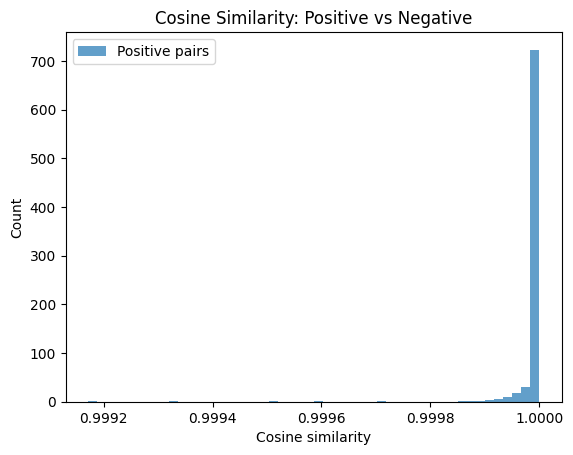

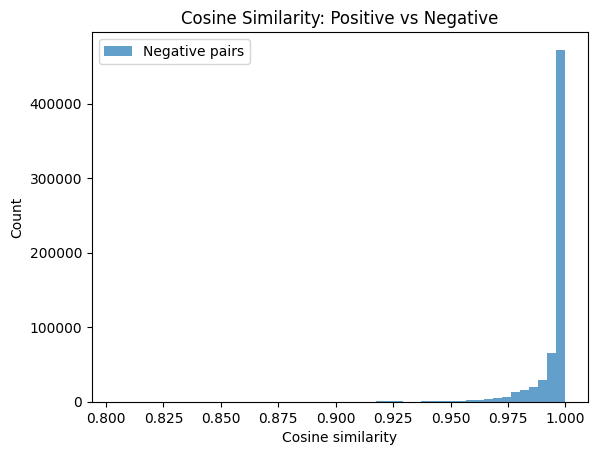

In [42]:
"""
Evaluating cosine similarity between positive and negative pairs
"""

'''
baseline 
'''

import numpy as np
import matplotlib.pyplot as plt

# ---- Load your data ----
orig = latents_no_crop_no_noise  # shape (N, d)
aug  = aug_latents_no_crop_no_noise   # shape (N, d)

# ---- Normalize vectors (IMPORTANT for cosine similarity) ----
def normalize(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

orig_norm = normalize(orig)
aug_norm  = normalize(aug)

# ---- Positive cosine similarities ----
pos_sim = np.sum(orig_norm * aug_norm, axis=1)  # shape (N,)

# ---- Negative cosine similarities ----
# full similarity matrix
sim_matrix = orig_norm @ aug_norm.T   # shape (N, N)

# remove diagonal (self-similarity)
mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
neg_sim = sim_matrix[mask]

# ---- Print summary stats ----
print("Positive cosine similarity:")
print("  mean =", np.mean(pos_sim))
print("  std  =", np.std(pos_sim))

print("\nNegative cosine similarity:")
print("  mean =", np.mean(neg_sim))
print("  std  =", np.std(neg_sim))

# ---- Histogram plot ----
plt.figure()
plt.hist(pos_sim, bins=50, alpha=0.7, label="Positive pairs")

plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.title("Cosine Similarity: Positive vs Negative")
plt.show()

plt.figure()

plt.hist(neg_sim, bins=50, alpha=0.7, label="Negative pairs")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.title("Cosine Similarity: Positive vs Negative")
plt.show()

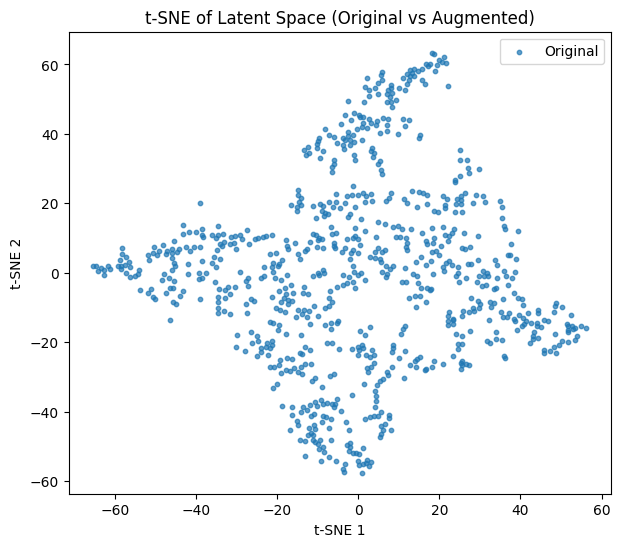

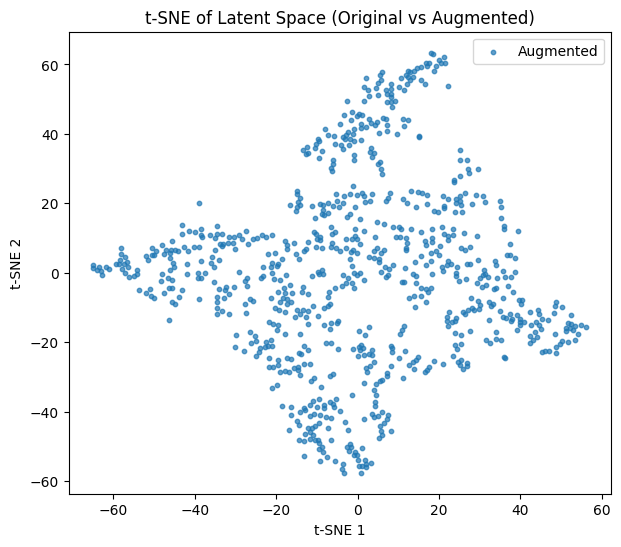

In [43]:
"""
tSNE projections
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---- labels for plotting ----
N = orig.shape[0]
X = np.vstack([orig, aug])
labels = np.array([0]*N + [1]*N)  # 0 = original, 1 = augmented

# ---- t-SNE ----
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_2d = tsne.fit_transform(X)

# split back
orig_2d = X_2d[:N]
aug_2d  = X_2d[N:]

# ---- plot ----
plt.figure(figsize=(7,6))

plt.scatter(orig_2d[:,0], orig_2d[:,1], s=10, label="Original", alpha=0.7)
#plt.scatter(aug_2d[:,0], aug_2d[:,1], s=10, label="Augmented", alpha=0.7)

plt.legend()
plt.title("t-SNE of Latent Space (Original vs Augmented)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

plt.figure(figsize=(7,6))

#plt.scatter(orig_2d[:,0], orig_2d[:,1], s=10, label="Original", alpha=0.7)
plt.scatter(aug_2d[:,0], aug_2d[:,1], s=10, label="Augmented", alpha=0.7)

plt.legend()
plt.title("t-SNE of Latent Space (Original vs Augmented)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

Positive cosine similarity:
  mean = 0.9999112
  std  = 0.0015714351

Negative cosine similarity:
  mean = -0.0010335792
  std  = 0.70754904


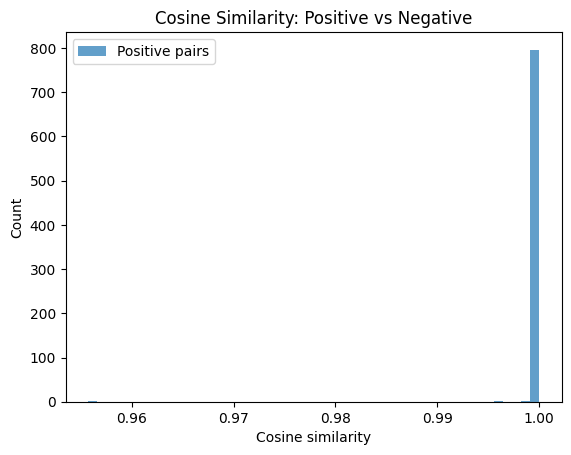

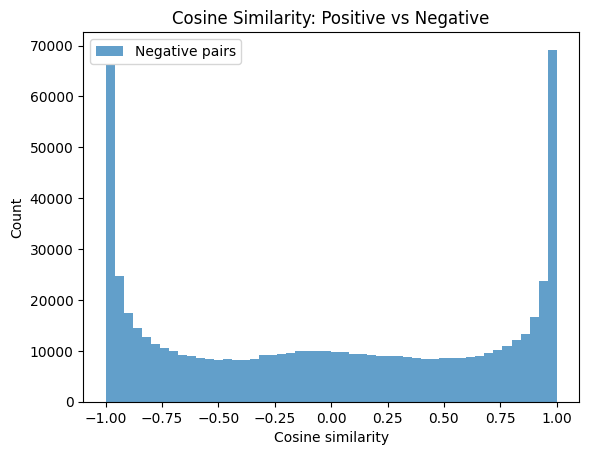

In [44]:
"""
Cosine Similarity in 2d space
"""


'''
baseline 
'''

import numpy as np
import matplotlib.pyplot as plt


def normalize(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

orig_norm = normalize(orig_2d)
aug_norm  = normalize(aug_2d)

# ---- Positive cosine similarities ----
pos_sim = np.sum(orig_norm * aug_norm, axis=1)  # shape (N,)

# ---- Negative cosine similarities ----
# full similarity matrix
sim_matrix = orig_norm @ aug_norm.T   # shape (N, N)

# remove diagonal (self-similarity)
mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
neg_sim = sim_matrix[mask]

# ---- Print summary stats ----
print("Positive cosine similarity:")
print("  mean =", np.mean(pos_sim))
print("  std  =", np.std(pos_sim))

print("\nNegative cosine similarity:")
print("  mean =", np.mean(neg_sim))
print("  std  =", np.std(neg_sim))

# ---- Histogram plot ----
plt.figure()
plt.hist(pos_sim, bins=50, alpha=0.7, label="Positive pairs")

plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.title("Cosine Similarity: Positive vs Negative")
plt.show()

plt.figure()

plt.hist(neg_sim, bins=50, alpha=0.7, label="Negative pairs")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.title("Cosine Similarity: Positive vs Negative")
plt.show()

Top 10 components explained variance:
PC1: 0.392848
PC2: 0.262995
PC3: 0.140199
PC4: 0.082050
PC5: 0.061993
PC6: 0.033135
PC7: 0.008727
PC8: 0.006837
PC9: 0.003218
PC10: 0.002170

Effective rank:
95% variance: 6
99% variance: 9


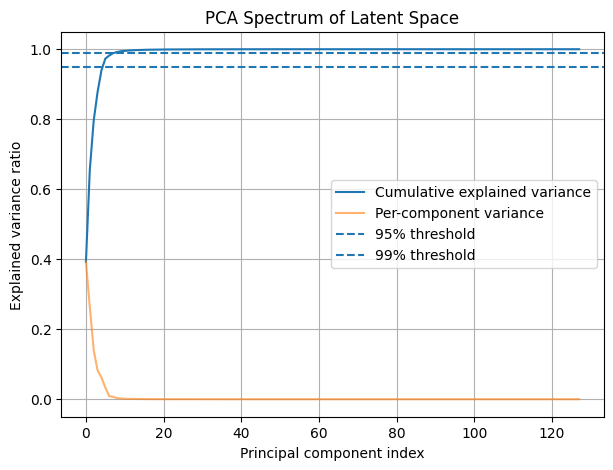

PC1 variance: 0.0008619392772080362
PC2 variance: 0.0005770308682478761
PC3 variance: 0.00030760765131676213
PC4 variance: 0.00018002442319999662
PC5 variance: 0.0001360179382017305


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---- load latent vectors ----
X = orig  # shape (N, d)

# ---- fit PCA ----
pca = PCA()
pca.fit(X)

# ---- explained variance ----
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# ---- print summary ----
print("Top 10 components explained variance:")
for i in range(10):
    print(f"PC{i+1}: {explained_var[i]:.6f}")

# effective rank (95% variance)
eff_rank_95 = np.argmax(cumulative_var >= 0.95) + 1
eff_rank_99 = np.argmax(cumulative_var >= 0.99) + 1

print("\nEffective rank:")
print("95% variance:", eff_rank_95)
print("99% variance:", eff_rank_99)

# ---- plot spectrum ----
plt.figure(figsize=(7,5))

plt.plot(cumulative_var, label="Cumulative explained variance")
plt.plot(explained_var, label="Per-component variance", alpha=0.6)

plt.axhline(0.95, linestyle="--", label="95% threshold")
plt.axhline(0.99, linestyle="--", label="99% threshold")

plt.xlabel("Principal component index")
plt.ylabel("Explained variance ratio")
plt.title("PCA Spectrum of Latent Space")
plt.legend()
plt.grid(True)

plt.show()


X = orig
pca = PCA(n_components=10)
Z = pca.fit_transform(X)

for i in range(5):
    print(f"PC{i+1} variance:", np.var(Z[:, i]))

In [9]:
"""
Linear probe comparison

"""


import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# ── 1. Regression targets ──────────────────────────────────────────────────
y_energy = np.array(dataset_test_total_energy)
y_hits   = np.array(dataset_test_num_hits)

# ── 2. Latent sets ─────────────────────────────────────────────────────────
latent_dict = {
    "crop + noise (baseline)":  latents_,
    "no crop":                  latents_no_crop,
    "no crop, no noise":        latents_no_crop_no_noise,
}

# ── 3. Train / eval helper ─────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV

def probe_accuracy(X, y, target_name, model_name, test_size=0.25, seed=42):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    # Also scale the target
    y_scaler = StandardScaler()
    y_tr_scaled = y_scaler.fit_transform(y_tr.reshape(-1, 1)).ravel()

    # Cross-validated alpha search over wide range
    model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10, 100, 1000, 10000])
    model.fit(X_tr, y_tr_scaled)
    
    y_pred_scaled = model.predict(X_te)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    r2   = r2_score(y_te, y_pred) * 100
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    print(f"  [{model_name}]  best_alpha={model.alpha_:.1f}  R²={r2:.2f}%  MAPE={mape:.2f}%")
    return {"model": model_name, "target": target_name, "R2_%": r2, "MAPE_%": mape}

# ── 4. Run probes for both targets ─────────────────────────────────────────
results = []
for target_name, y in [("total_energy", y_energy), ("num_hits", y_hits)]:
    print(f"\n── Target: {target_name} ──")
    for model_name, X in latent_dict.items():
        results.append(probe_accuracy(X, y, target_name, model_name))

# ── 5. Summary table ───────────────────────────────────────────────────────
import pandas as pd
df = pd.DataFrame(results).pivot(index="model", columns="target", values=["R2_%", "MAPE_%"])
df.columns = [f"{t} {m}" for m, t in df.columns]   # flatten MultiIndex
print("\n── Summary ──")
print(df.to_string(float_format="%.2f"))


── Target: total_energy ──
  [crop + noise (baseline)]  best_alpha=100.0  R²=-18.01%  MAPE=38.96%
  [no crop]  best_alpha=10.0  R²=-1.79%  MAPE=38.60%
  [no crop, no noise]  best_alpha=100.0  R²=-41.46%  MAPE=39.37%

── Target: num_hits ──
  [crop + noise (baseline)]  best_alpha=1000.0  R²=-2.66%  MAPE=31.23%
  [no crop]  best_alpha=100.0  R²=-16.40%  MAPE=31.47%
  [no crop, no noise]  best_alpha=100.0  R²=-17.65%  MAPE=31.54%

── Summary ──
                         num_hits R2_%  total_energy R2_%  num_hits MAPE_%  total_energy MAPE_%
model                                                                                          
crop + noise (baseline)          -2.66             -18.01            31.23                38.96
no crop                         -16.40              -1.79            31.47                38.60
no crop, no noise               -17.65             -41.46            31.54                39.37


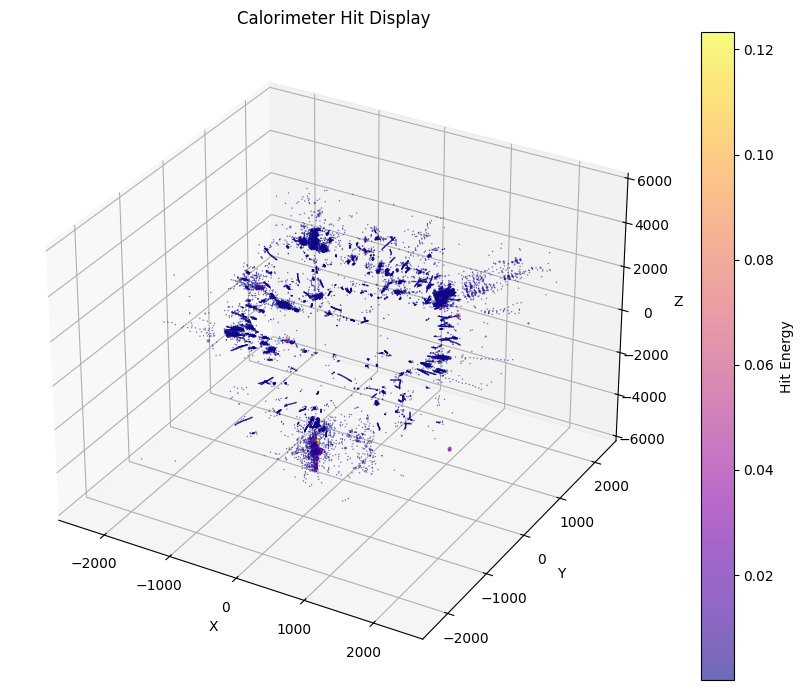

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def plot_event_3d(event, ax=None, title="Calorimeter Hit Display"):
    hits = event["calo_hit_features"]  # (N, 4): x, y, z, E
    x, y, z, E = hits[:, 0], hits[:, 1], hits[:, 2], hits[:, 3]

    if ax is None:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=E, cmap='plasma', 
                    s=np.clip(E / E.max() * 30, 1, 30),  # size ~ energy
                    alpha=0.6, linewidths=0)
    plt.colorbar(sc, ax=ax, label='Hit Energy')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    return ax

# Plot first event
event = next(iter(dataset_test_))
plot_event_3d(event)
plt.tight_layout()
plt.show()

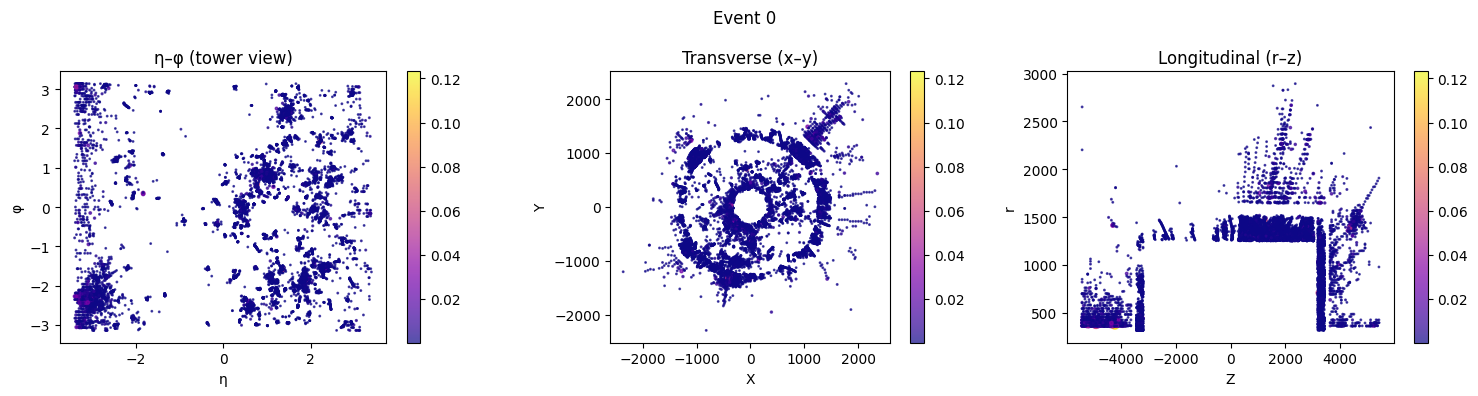

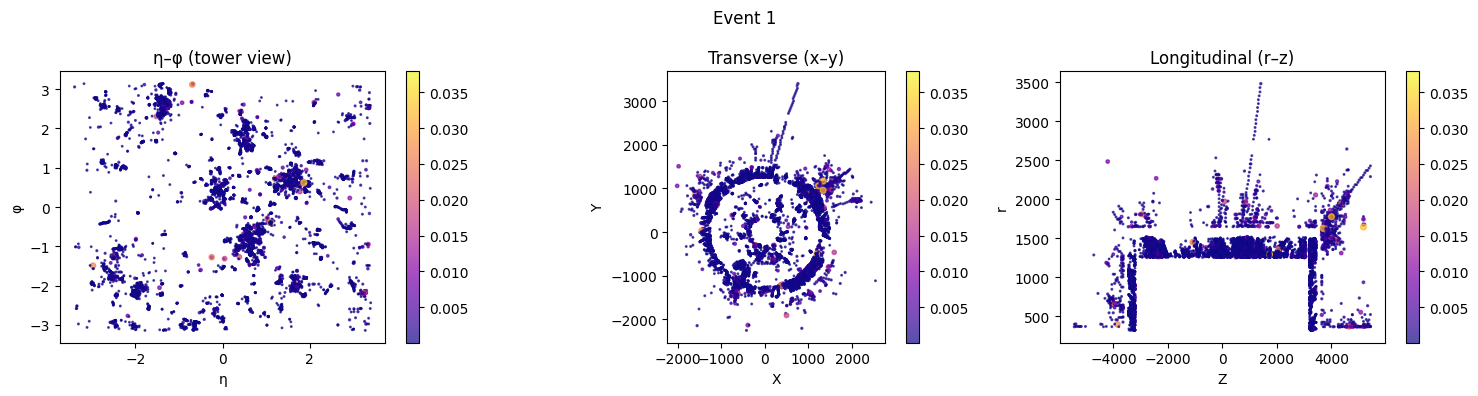

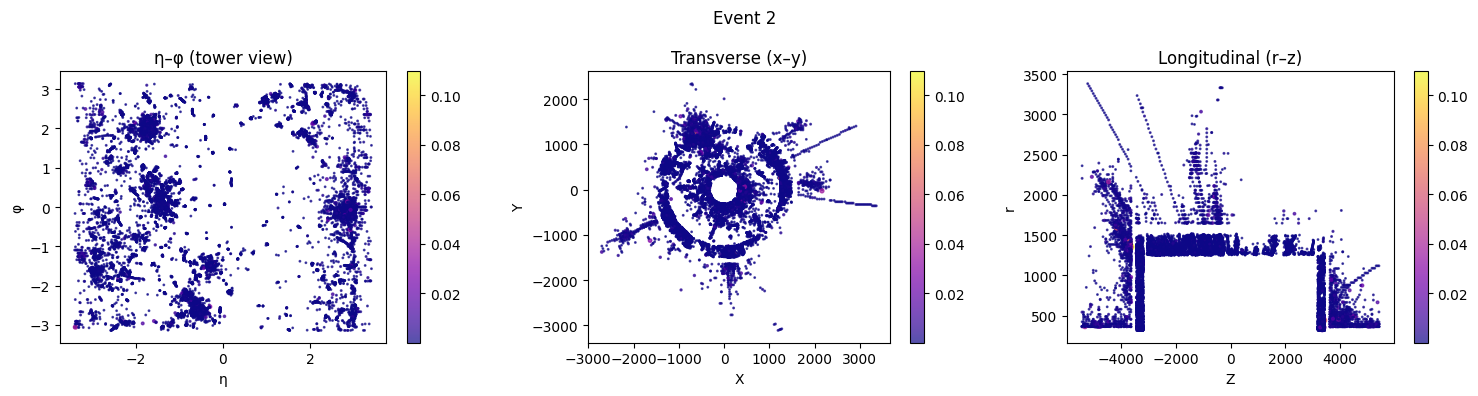

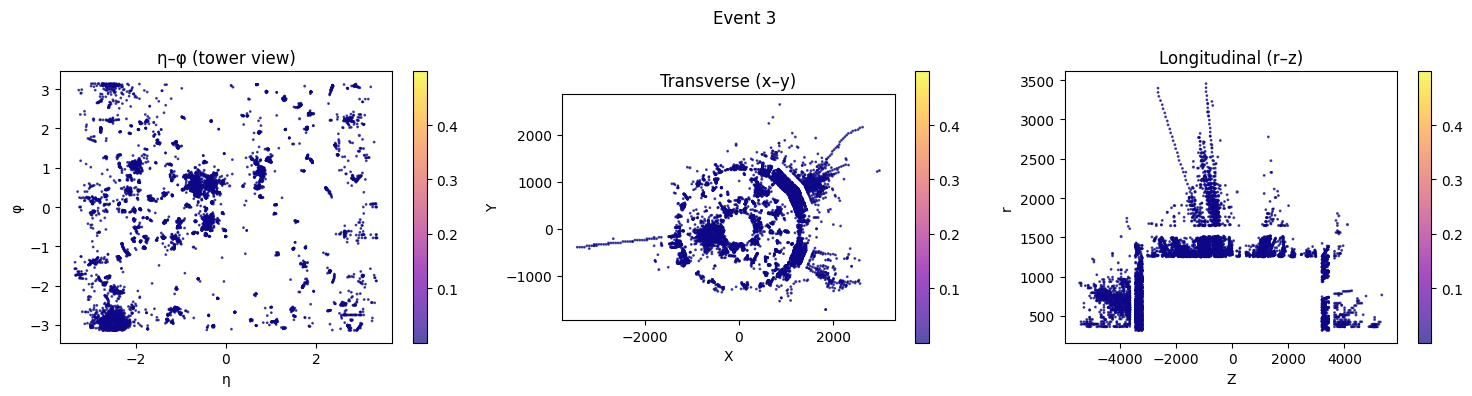

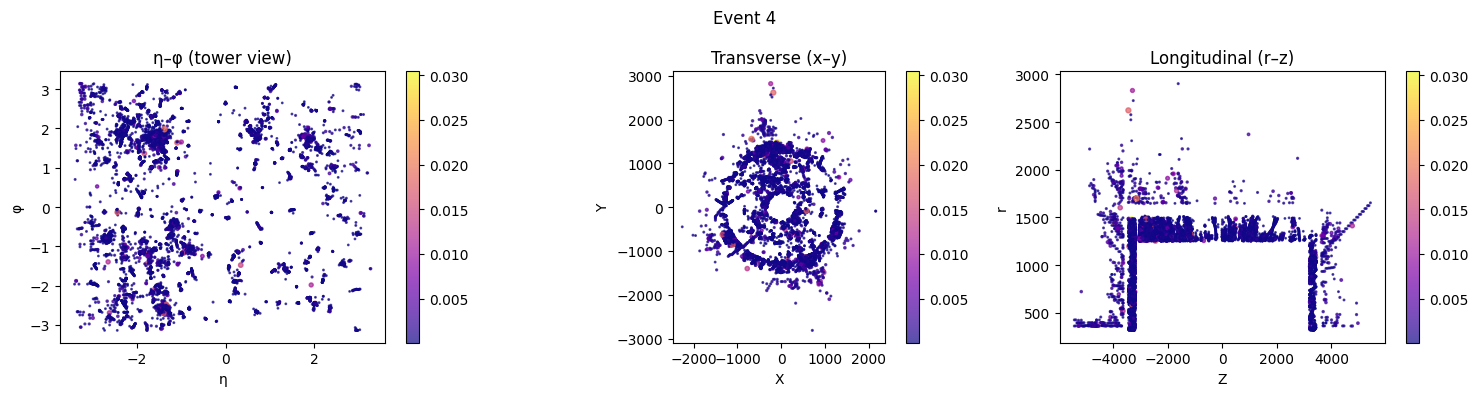

In [12]:
def plot_projections(event, title=""):
    hits = event["calo_hit_features"]
    x, y, z, E = hits[:, 0], hits[:, 1], hits[:, 2], hits[:, 3]

    # Cylindrical coordinates
    r   = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    eta = -np.log(np.tan(np.arctan2(r, np.abs(z)) / 2)) * np.sign(z)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)

    # η-φ (classic detector view)
    sc0 = axes[0].scatter(eta, phi, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[0].set_xlabel('η'); axes[0].set_ylabel('φ')
    axes[0].set_title('η–φ (tower view)'); plt.colorbar(sc0, ax=axes[0])

    # x-y (transverse plane)
    sc1 = axes[1].scatter(x, y, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
    axes[1].set_title('Transverse (x–y)'); plt.colorbar(sc1, ax=axes[1])
    axes[1].set_aspect('equal')

    # r-z (longitudinal slice)
    sc2 = axes[2].scatter(z, r, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[2].set_xlabel('Z'); axes[2].set_ylabel('r')
    axes[2].set_title('Longitudinal (r–z)'); plt.colorbar(sc2, ax=axes[2])

    plt.tight_layout()
    plt.show()

events = []
iter_data = iter(dataset_test_)
for _ in range(5):
    events.append(next(iter_data))

for i, event in enumerate(events):
    plot_projections(event, title=f"Event {i}")